In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Print imported modules for verification
print("All necessary libraries imported successfully.")
print(f"TensorFlow version: {tf.__version__}")

All necessary libraries imported successfully.
TensorFlow version: 2.19.0


Loading the ORL (Olivetti) face dataset...

Total samples: 400
Image dimensions: 64x64 pixels
Number of classes (people): 40
Sample labels: [20 28  3 21  9  8 32  9 26 12]
Min/Max pixel values: 0.0 / 1.0
Images shape: (400, 64, 64)
Labels shape: (400,)

Displaying a few example faces from the dataset:


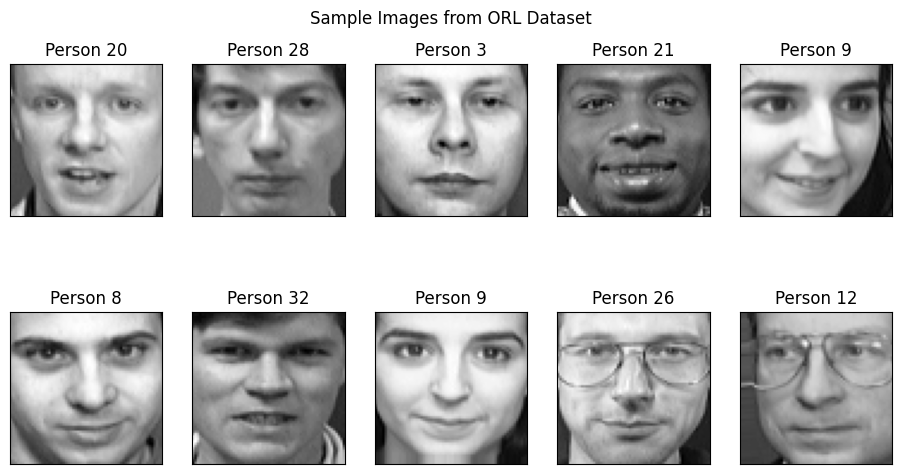

In [ ]:
print("Loading the ORL (Olivetti) face dataset...")
olivetti = fetch_olivetti_faces(shuffle=True, random_state=42)

y = olivetti.target
X_images = olivetti.images

n_samples, h, w = X_images.shape
n_classes = len(np.unique(y))

# Print key dataset values
print(f"\nTotal samples: {n_samples}")
print(f"Image dimensions: {h}x{w} pixels")
print(f"Number of classes (people): {n_classes}")
print(f"Sample labels: {y[:10]}")
print(f"Min/Max pixel values: {np.min(X_images)} / {np.max(X_images)}")
print(f"Images shape: {X_images.shape}")
print(f"Labels shape: {y.shape}")

# Visualize some faces
def plot_faces(images, labels, n_row=2, n_col=5):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i], cmap=plt.cm.gray)
        plt.title(f"Person {labels[i]}", size=12)
        plt.xticks(())
        plt.yticks(())
    plt.suptitle("Sample Images from ORL Dataset")
    plt.show()

print("\nDisplaying a few example faces from the dataset:")
plot_faces(X_images, y)

In [ ]:
X_cnn = X_images.reshape(n_samples, h, w, 1)  # Add channel dimension
y_cat = to_categorical(y, num_classes=n_classes)  # One-hot encode labels

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cat, test_size=0.25, random_state=42, stratify=y
)

# Print key preprocessing values
print("\nData has been split and preprocessed for the CNN.")
print(f"CNN model training set size: {X_train_cnn.shape[0]}")
print(f"CNN model test set size: {X_test_cnn.shape[0]}")
print(f"Train shape (CNN): {X_train_cnn.shape}")
print(f"Test shape (CNN): {X_test_cnn.shape}")
print(f"Train labels shape (one-hot): {y_train_cnn.shape}")
print(f"Test labels shape (one-hot): {y_test_cnn.shape}")
print(f"Stratified split used for balanced classes.")
print(f"Number of classes in one-hot: {n_classes}")


Data has been split and preprocessed for the CNN.
CNN model training set size: 300
CNN model test set size: 100
Train shape (CNN): (300, 64, 64, 1)
Test shape (CNN): (100, 64, 64, 1)
Train labels shape (one-hot): (300, 40)
Test labels shape (one-hot): (100, 40)
Stratified split used for balanced classes.
Number of classes in one-hot: 40


In [ ]:
print("\n--- Building State-of-the-Art Convolutional Neural Network (CNN) ---")

# Define hyperparameters for layers
filters1 = 32
filters2 = 64
filters3 = 128
kernel_size = (3, 3)
pool_size = (2, 2)
dense_units = 256
dropout_rate = 0.5
input_shape = (h, w, 1)

# Print layer hyperparameters
print(f"CNN Layer Hyperparameters - Filters: {filters1}/{filters2}/{filters3}, Kernel: {kernel_size}, Pool: {pool_size}")
print(f"Dense units: {dense_units}, Dropout: {dropout_rate}, Input shape: {input_shape}")

cnn_model = Sequential([
    Conv2D(filters1, kernel_size, activation='relu', padding='same', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D(pool_size),
    Conv2D(filters2, kernel_size, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size),
    Conv2D(filters3, kernel_size, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size),
    Flatten(),
    Dense(dense_units, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),
    Dense(n_classes, activation='softmax')
])

# Define compile hyperparameters
learning_rate = 0.001
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
loss = 'categorical_crossentropy'
metrics = ['accuracy']

# Print compile hyperparameters
print(f"CNN Compile Hyperparameters - Optimizer: Adam, Learning rate: {learning_rate}, Loss: {loss}, Metrics: {metrics}")

cnn_model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
cnn_model.summary()


--- Building State-of-the-Art Convolutional Neural Network (CNN) ---
CNN Layer Hyperparameters - Filters: 32/64/128, Kernel: (3, 3), Pool: (2, 2)
Dense units: 256, Dropout: 0.5, Input shape: (64, 64, 1)
CNN Compile Hyperparameters - Optimizer: Adam, Learning rate: 0.001, Loss: categorical_crossentropy, Metrics: ['accuracy']


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,202,280 (8.40 MB)

 Trainable params: 2,201,320 (8.40 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Define callbacks with hyperparameters
patience_es = 15
patience_rlr = 5
factor_rlr = 0.1
min_lr = 0.00001

# Print callback hyperparameters
print(f"EarlyStopping - Monitor: val_accuracy, Patience: {patience_es}")
print(f"ReduceLROnPlateau - Monitor: val_loss, Factor: {factor_rlr}, Patience: {patience_rlr}, Min LR: {min_lr}")

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=patience_es, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=factor_rlr, patience=patience_rlr, min_lr=min_lr, verbose=1)
]

# Define training hyperparameters
epochs = 100
batch_size = 16

# Print training hyperparameters
print(f"Training Hyperparameters - Epochs: {epochs}, Batch size: {batch_size}")

print("\n--- Training the CNN Model ---")
history = cnn_model.fit(X_train_cnn, y_train_cnn,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(X_test_cnn, y_test_cnn),
                        callbacks=callbacks,
                        verbose=1)

# Print post-training values
print(f"Training completed after {len(history.history['loss'])} epochs.")
print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final training loss: {history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {history.history['val_loss'][-1]:.4f}")

EarlyStopping - Monitor: val_accuracy, Patience: 15
ReduceLROnPlateau - Monitor: val_loss, Factor: 0.1, Patience: 5, Min LR: 1e-05
Training Hyperparameters - Epochs: 100, Batch size: 16

--- Training the CNN Model ---
Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 246ms/step - accuracy: 0.1911 - loss: 3.5408 - val_accuracy: 0.0300 - val_loss: 3.8796 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 275ms/step - accuracy: 0.8343 - loss: 0.8424 - val_accuracy: 0.0300 - val_loss: 5.5777 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9851 - loss: 0.2529 - val_accuracy: 0.0300 - val_loss: 7.3895 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 152ms/step - accuracy: 0.9919 - loss: 0.1276 - val_accuracy: 0.0400 - val_loss: 9.0407 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 1.0000 - loss: 0.0781 - val_accuracy: 0.0500 - val_loss: 10.5304 - learning_rate: 0.0010
Epoch 6/100
19/1

In [ ]:
print("\n--- Evaluating the CNN Model ---")
score = cnn_model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
cnn_accuracy = score[1]
test_loss = score[0]

# Print evaluation values
print(f"\nCNN Test Accuracy: {cnn_accuracy * 100:.2f}%")
print(f"CNN Test Loss: {test_loss:.4f}")

# Generate predictions for the report and matrix
y_pred_cnn_probs = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)
y_test_labels_cnn = np.argmax(y_test_cnn, axis=1)

print("\nCNN Classification Report:")
print(classification_report(y_test_labels_cnn, y_pred_cnn))


--- Evaluating the CNN Model ---

CNN Test Accuracy: 5.00%
CNN Test Loss: 10.5304
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

CNN Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         2
          10       0.00      0.00      0.00         3
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Visualizing some test predictions (Correct: Green, Incorrect: Red):


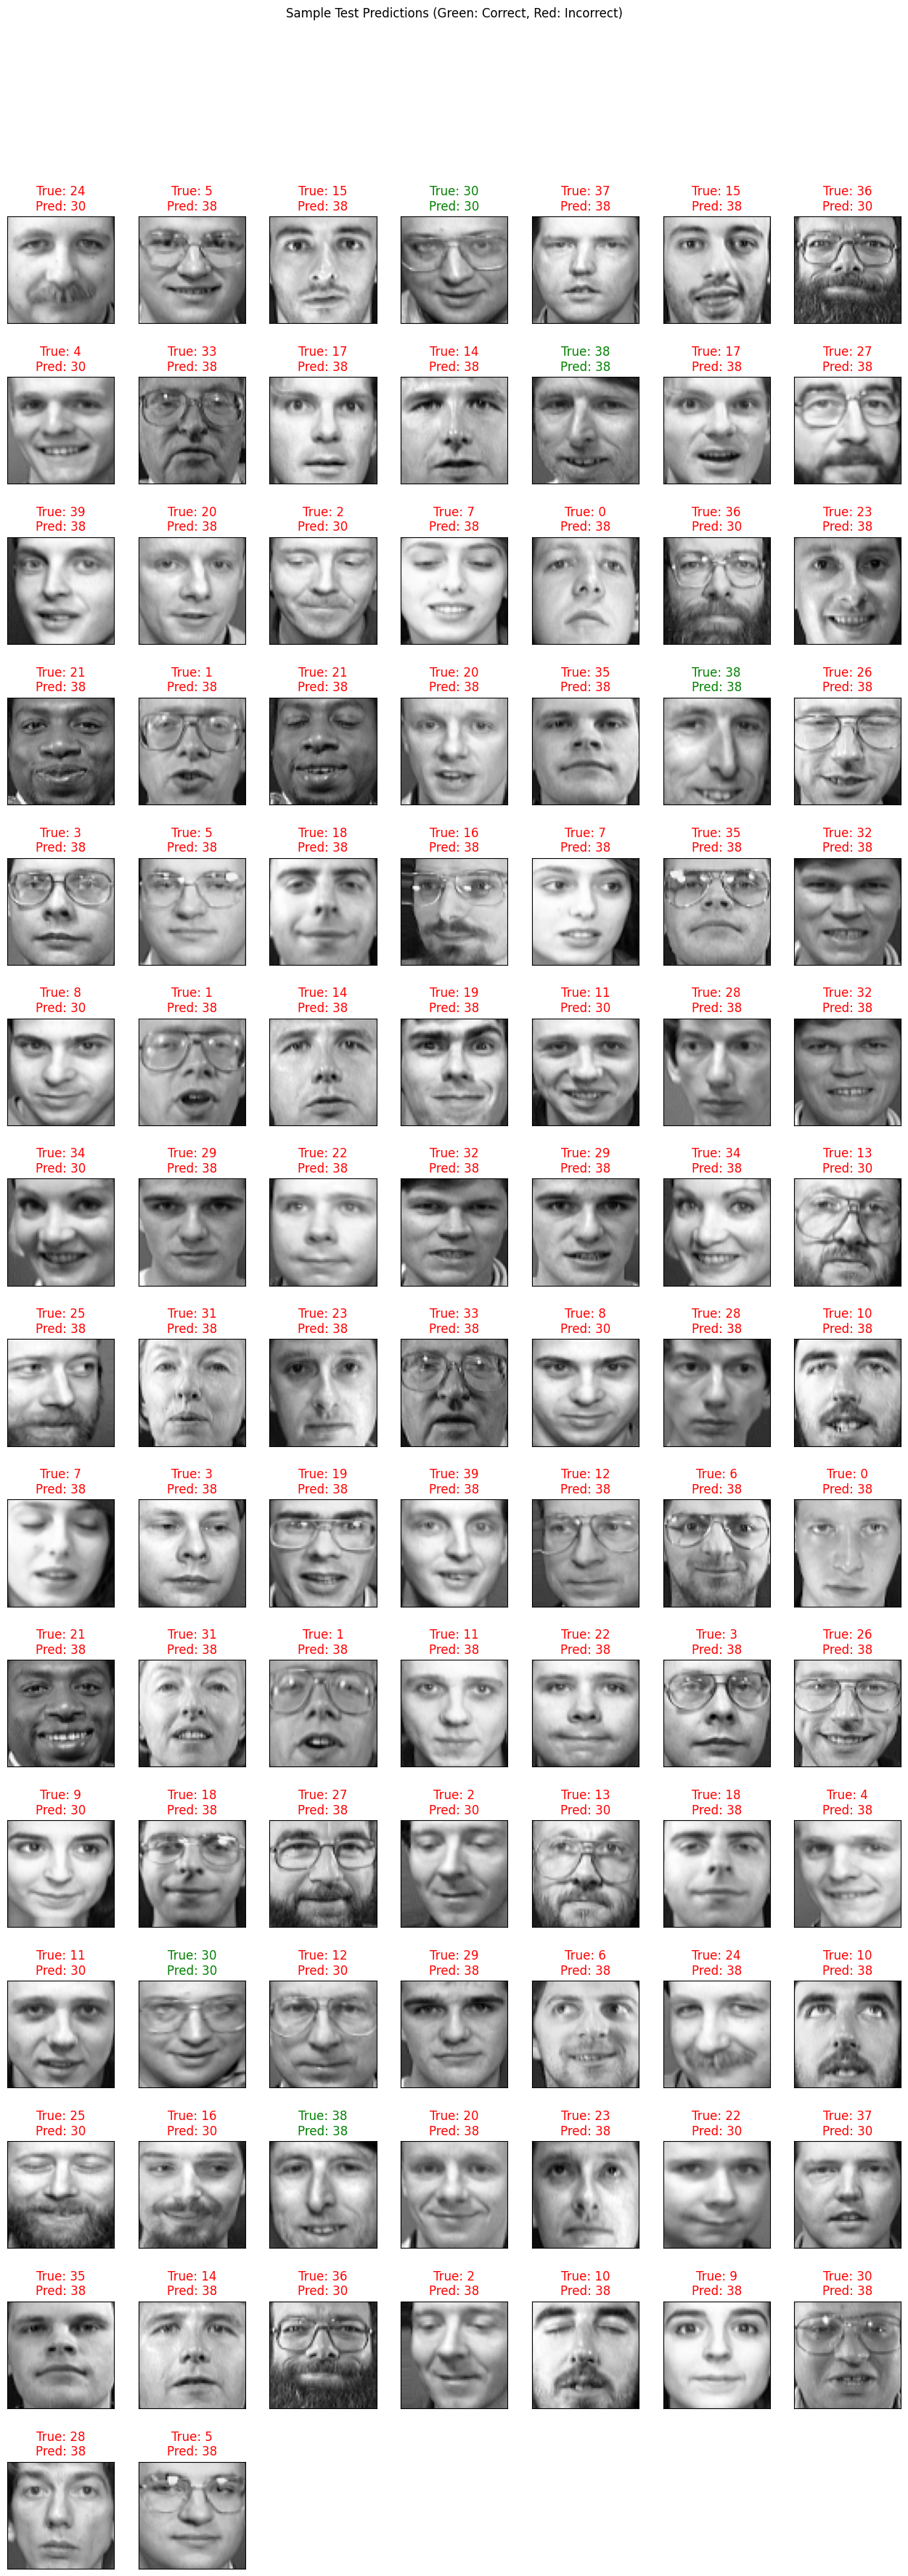

In [ ]:
def plot_prediction_results(images, true_labels, pred_labels, n_row=15, n_col=7):
    """Helper function to plot prediction results"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.5)
    # Get the first n_row * n_col samples for plotting
    num_images_to_plot = min(len(images), n_row * n_col)
    for i in range(num_images_to_plot):
        plt.subplot(n_row, n_col, i + 1)
        # Reshape image from (h, w, 1) to (h, w) for imshow
        plt.imshow(images[i].reshape((64, 64)), cmap=plt.cm.gray)
        title_color = 'green' if true_labels[i] == pred_labels[i] else 'red'
        plt.title(f"True: {true_labels[i]}\nPred: {pred_labels[i]}", color=title_color, size=12)
        plt.xticks(())
        plt.yticks(())
    plt.suptitle("Sample Test Predictions (Green: Correct, Red: Incorrect)")
    plt.show()

print("\nVisualizing some test predictions (Correct: Green, Incorrect: Red):")
plot_prediction_results(X_test_cnn, y_test_labels_cnn, y_pred_cnn)


--- Plotting Model Training History ---


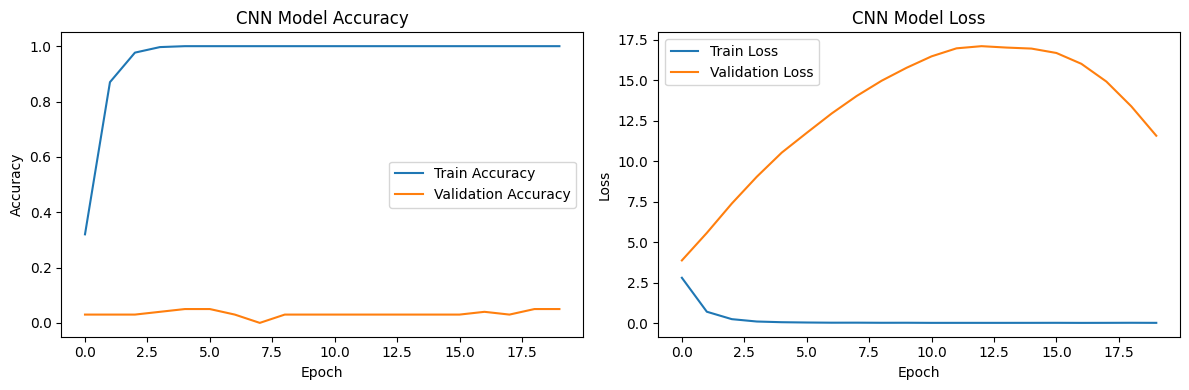

In [ ]:
print("\n--- Plotting Model Training History ---")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


--- Plotting Confusion Matrix ---


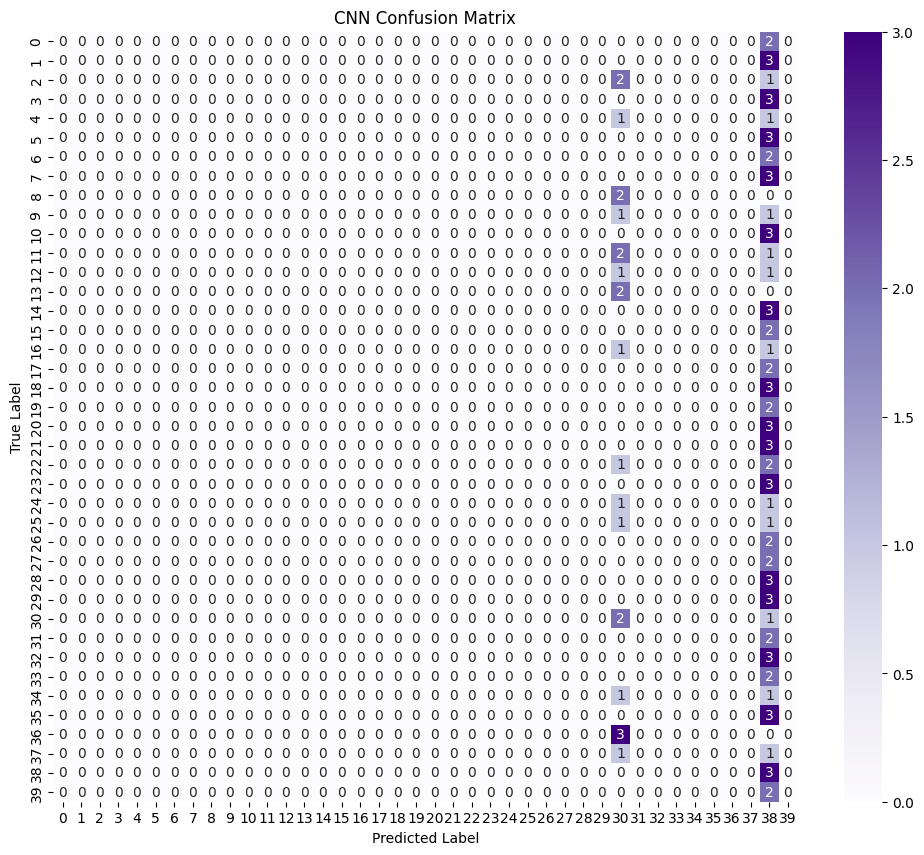


--- CNN Session Complete ---


In [ ]:
print("\n--- Plotting Confusion Matrix ---")
cm_cnn = confusion_matrix(y_test_labels_cnn, y_pred_cnn)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Purples')
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n--- CNN Session Complete ---")